# Numerical Methods


The aim of this unit will be to help us understand how we go from thinking about things fully theoretically, to making them numeric.

* In this way we'll lose some generality, as we won't be able to think about things abstractly
* But we'll also gain a whole bunch of concrete detail


In general, as part of my process, I tend to start out with fully analytical models:
* This is where you figure out the moving parts
* What are inputs/outputs
* What's the objective here, etc

But at some point the model either gets too complicated to solve, or I'm trying to move the model to data to estimate things concretely, at which point we move from having a theoretical model on a piece of paper, to trying to get this model to engage with numbers.

Today we'll go through ways to mirror some of the analysis skills we've used in the theory sections, but within the computer.

To do this, we'll switch from analytical representations, into numerical, and detail what we gain from this, and what we need to be concerned with.


# Numerical Methods

Our aims is to go over three key numerical tools:
1. Numerical derivatives
2. Numerical solutions to equations
3. Numerical Optimization (next notebook)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import math

PITT_BLUE = "#003594"
PITT_GOLD = "#FFB81C"
PITT_DGRAY = "#75787B"
PITT_GRAY = "#97999B"
PITT_LGRAY = "#C8C9C7"

I took these colors from the [Pitt Brand Identity website](https://www.brand.pitt.edu/visual-identity)

## Linear Equations

Suppose that we have a simple system of equations:
$$ \begin{array}{rcl} 2 x_1+ 3 x_2 & = & 6 \\  x_1+ x_2 & = & 2 \end{array}$$


You probably solved this type of equation in high school, and the unique solution is:
$$ \begin{array}{rcl} x_1 & = & 0 \\  x_2 & = & 2 \end{array}$$


We can represent this as a linear system:
$$\begin{array}{rcl} 2 x_1+ 3 x_2 & = & 6 \\  x_1+ x_2 & = & 2 \end{array} \Rightarrow \left[ \begin{array}{cc}
 2 & 3 \\ 
 1 & 1 \end{array}\right] 
 \left(\begin{array}{c}x_1\\x_2\end{array}\right)= \left(\begin{array}{c}6\\2\end{array}\right)
 $$
 
So the linear equation system is $\mathbf{A}\mathbf{x}=\mathbf{c}$

In [2]:
# Define the matrices
A = np.array([[2, 3], 
              [1, 1]])
c = np.array([6, 2])

In [3]:
# Solve using np.linalg.solve
x = np.linalg.solve(A, c)
print(x)

[0. 2.]


In [5]:
# Alternatively, using matrix inverse
A_inv = np.linalg.inv(A)
x_via_inv = A_inv @ c  # @ is matrix multiplication in Python
x_via_inv

array([0., 2.])

While this example we could have done more quickly by hand, once the number of equations becomes large, linear algebra becomes very useful.

Implicitly, you've been using the benefits of this in the last semseter, because you were trying to minimize the total sum of squares for a regression model
$$ \sum_i\left(y_{i}-(\beta_0+\beta_1 x_{i,1}+\ldots +\beta_k x_{i,k})\right)^2 $$

Taking first-order conditions to try to get each term minimized led to $k+1$ equations in the $k+1$ unknowns (the $\beta$ terms)

It's possible to make the above simpler to represent $\mathbf{y}$ and $\boldsymbol{\beta}$ as vectors, and $\mathbf{X}$ as the $n\times (k+1)$ data matrix.

At the end of the day though, the first-order conditions imply a system of linear equations:
$$\mathbf{A} \hat{\boldsymbol{\beta}}=\mathbf{c}$$
(where the additional structure told us that $\mathbf{A}=\mathbf{X}^T\mathbf{X}$ and $\mathbf{c}=\mathbf{X}^T\mathbf{y}$)

The benefit of being able to solve linear equations is that we got a nice analytical expression for the estimates:
$$ \hat{\boldsymbol{\beta} }= (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} $$

The point of this is:
* Some brief review of linear algebra
* Solving linear equations is mechanical so long as you've got the right numbers of unknowns and equations
* In the OLS model where we optimized to **minimize** the sum of squares, the output formula was easy to work with

# Numerical Methods

So, having gone over a very simple set of equations, let's come back to option 1 here.
1. Numerical derivatives
2. Numerical solutions to equations
3. Numerical Optimization

### Easy Ones
Sometimes it is trivial for us to take a derivative:
$$ f(x)=a x^2+b x+c$$


Solution:

$$ f^\prime(x)=2 a x+b $$

### Medium Ones

Other times, we can probably solve something, it just takes us a bit longer:
$$ f(x)=(a x^2+b x+c)\cdot e^{-\lambda x}$$


Solution:

$$ f^\prime(x)=-\lambda e^{-\lambda x}(a x^2 +bx +c)+e^{-\lambda x}(2ax+b)$$


### Hurt-Your-Head Ones

And still other times, it's just not worth really thinking about the analytical formula.... Consider the function:
$$f(x)=\sqrt{x^2 e^{\sin(x)}+\Phi(x \cdot \log(x+1))}$$

where $\Phi$ is the standard normal CDF.

The analytical derivative of this function is:

$$f'(x)=\frac{x^2 e^{\sin(x)}\cos(x)+2x e^{\sin(x)}+\Phi'(x\log(x+1))\left(\log(x+1)+\frac{x}{x+1}\right)}{2\sqrt{x^2 e^{\sin(x)}+\Phi(x \cdot \log(x+1))}}$$

...which is why numerical derivatives are so practical! Rather than spending time deriving and debugging these formulas, we can just let the computer approximate them for us.

## Gradients & Derivatives


### Discrete changes
A lot of the time when we're thinking about changes, it's usually a discrete quantity change:
$$x\mapsto x+\Delta x$$ 

The underlying gradient is the ratio of the movements:
$$ \frac{\Delta y}{\Delta x}=\frac{f(x+\Delta x)-f(x)}{\Delta x} $$


### Derivatives
As we make the change in $x$ smaller and smaller, this gradient approaches the derivative:
$$\frac{dy}{dx}= \lim_{\Delta x\rightarrow 0} \frac{f(x+\Delta x)-f(x)}{\Delta x}$$

Rather than the exact limit, we can therefore try to numerically approximate the derivative by a using a very small value of the input change $\Delta x$. 

* That is, we will choose $\Delta x$ to be suitably small number $\epsilon$

* However, we can't make $\epsilon$ too small, as we can get into problems with how computers store numbers!
  

We can write this in code.

In [6]:
# Define a numerical derivative function
def num_deriv(f, x, eps):
    """Forward difference numerical derivative."""
    return (f(x + eps) - f(x)) / eps

### Coding it up: Easy Example

Let's go back to our simplest example $f(x)=a x^2+b x+c$,
but where we make the problem exact by setting $a=2$, $b=-10$ and $c=3$

So:
* $f(x)=2 x^2- 10 x+3$
* $f^\prime(x)=4 x-10$

In [7]:
# Define the function we're interested in taking derivatives of
def easy_f(x):
    """f(x) = 2x^2 - 10x + 3"""
    return 2*x**2 - 10*x + 3

# Define the actual (analytical) derivative
def d_easy_f(x):
    """f'(x) = 4x - 10"""
    return 4*x - 10

In [8]:
# Take Numerical Derivatives!
eps = 1e-7
nd = num_deriv(easy_f, 3, eps)
ad = d_easy_f(3)
err = nd - ad

print(f"Numerical derivative:  {nd:.10f}")
print(f"Analytical derivative: {ad:.10f}")
print(f"Error:                 {err:.2e}")

Numerical derivative:  2.0000002010
Analytical derivative: 2.0000000000
Error:                 2.01e-07


## Coding it up: Medium Example

Let's try our medium example where we'll just take the product of our previous quadratic function with an exponential function:

$$\left(2 x^2- 10 x+3 \right)e^{-x/10}$$

In [9]:
# Define the medium-hard function
def med_f(x):
    """f(x) = (2x^2 - 10x + 3) * exp(-x/10)"""
    return easy_f(x) * np.exp(-x/10)

# Analytical derivative using product rule
def d_med_f(x):
    """f'(x) = -0.1*exp(-0.1x)*(2x^2-10x+3) + exp(-0.1x)*(4x-10)"""
    return -0.1 * np.exp(-0.1*x) * easy_f(x) + np.exp(-0.1*x) * (4*x - 10)

In [10]:
# Take Numerical Derivatives!
eps = 1e-5
nd = num_deriv(med_f, 3, eps)
ad = d_med_f(3)
err = nd - ad

print(f"Numerical derivative:  {nd:.10f}")
print(f"Analytical derivative: {ad:.10f}")
print(f"Error:                 {err:.2e}")

Numerical derivative:  2.1483858413
Analytical derivative: 2.1483728400
Error:                 1.30e-05


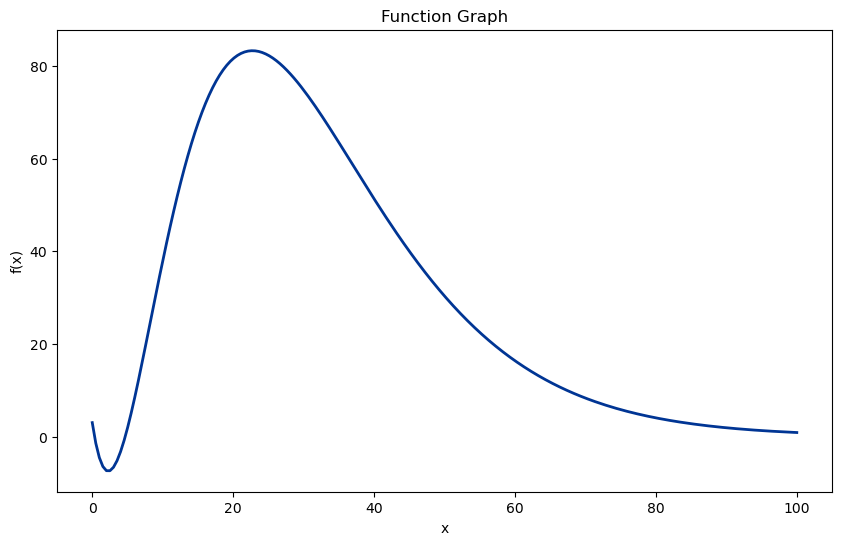

In [11]:
# Draw a graph of the function
x = np.linspace(0, 100, 200)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, med_f(x), color=PITT_BLUE, linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Function Graph')
plt.show()

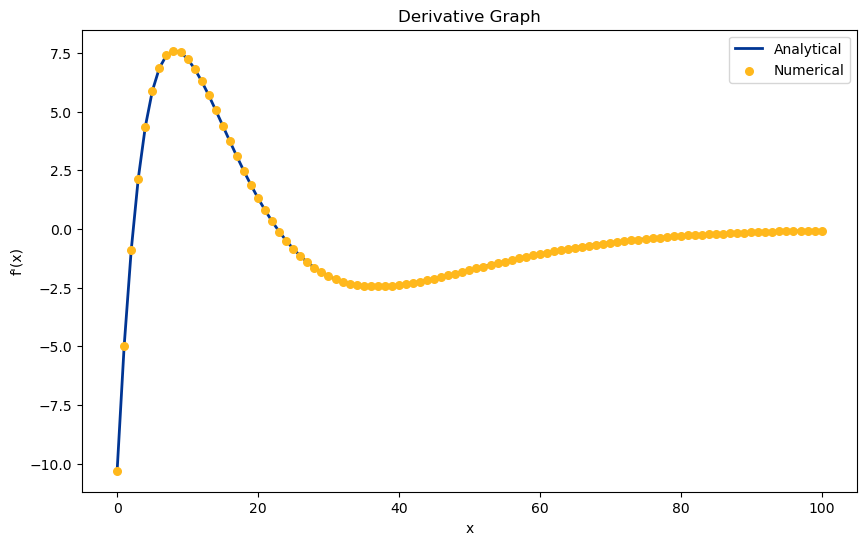

In [12]:
# Create numerical derivatives for every x from 0 to 100
x_range = np.arange(0, 101)
nd_med_f = np.array([num_deriv(med_f, xi, 1e-5) for xi in x_range])

# Draw both analytical and numerical derivatives
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, d_med_f(x_range), color=PITT_BLUE, linewidth=2, label='Analytical')
ax.scatter(x_range, nd_med_f, color=PITT_GOLD, s=30, zorder=5, label='Numerical')
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.set_title('Derivative Graph')
ax.legend()
plt.show()

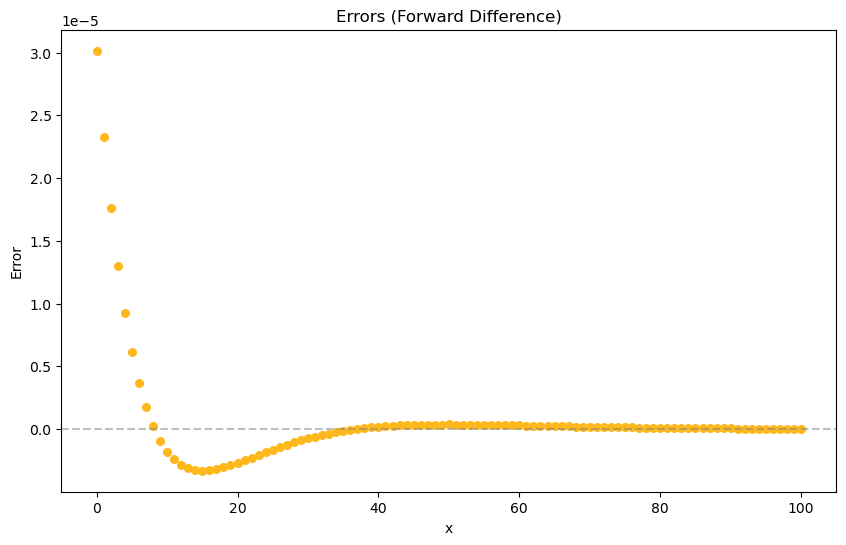

In [13]:
# Graph the errors (numerical - actual)
nd_med_f_error = nd_med_f - d_med_f(x_range)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_range, nd_med_f_error, color=PITT_GOLD, s=30)
ax.set_xlabel('x')
ax.set_ylabel('Error')
ax.set_title('Errors (Forward Difference)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.show()

## What about higher-order derivatives?

Suppose that we want to get a numerical version of the second derivative $\tfrac{d^2}{dx^2}f(x)$.

One way would be to just define this via the iterated procedure, where the second derivative is just the derivative of the derivative...

So we want to try and approximate:
$$\tfrac{d^2}{dx^2}f(x)=\tfrac{d}{dx}f^\prime(x)= \lim_{\Delta x\rightarrow 0} \frac{f^\prime(x+\Delta x)-f^\prime(x)}{\Delta x}$$
through a small increment $\epsilon$

And we could plug in  numerical approximation for the derivative at $x$:
$$f^\prime_\epsilon(x)= \frac{f(x+\epsilon)-f(x)}{\epsilon}$$

and at $x+\epsilon$
$$f^\prime_\epsilon(x+\epsilon)= \frac{f(x+2\epsilon)-f(x+\epsilon)}{\epsilon}$$

One approximation for the second-derivative would then be to look at how the numerical slope of $f(x)$ changes across the increment $\epsilon$:
$$f^{\prime\prime}_\epsilon(x)= \frac{f^\prime(x+\epsilon)-f^\prime(x)}{\epsilon}$$

Where if you went through the prior formulas you'd find that this approximation is actually:
$$f^{\prime\prime}_\epsilon(x)=\frac{f(x+2\epsilon)-2 f(x+\epsilon)+f(x)}{\epsilon^2 }$$

In [14]:
# Coding this up as a formula we get
def num_deriv_2(f, x, eps):
    """Forward difference second derivative."""
    return (f(x + 2*eps) - 2*f(x + eps) + f(x)) / eps**2

Thinking back to our easy formula as a test for this, what's the second derivative of:
$$ 2 x^2- 10 x+3 $$

In [15]:
num_deriv_2(easy_f, 2, 1e-4)

3.999999975690116

## Are there better, more accurate formulas?

One way to think through this procedure is to consider the **Taylor expansion** of the function around the point $x$ for any deviation $\Delta x$
$$f(x+\Delta x)=f(x)+\frac{f^\prime(x)}{1!}\Delta x+\frac{f^{\prime\prime}(x)}{2!}\Delta x^2+\frac{f^{\prime\prime\prime}(x)}{3!}\Delta x^3+\ldots$$

### Taylor Expansion

$$f(x+\Delta x)=f(x)+\frac{f^\prime(x)}{1!}\Delta x+\frac{f^{\prime\prime}(x)}{2!}\Delta x^2+\frac{f^{\prime\prime\prime}(x)}{3!}\Delta x^3+\ldots$$

Let $\Delta x$ be our small increment $\epsilon$ in the numerical derivative formula, raising $\epsilon$ to increasing powers makes each of the successive terms even smaller,
$$f(x+\epsilon)=f(x)+\frac{f^\prime(x)}{1!}\epsilon+\frac{f^{\prime\prime}(x)}{2!}\epsilon^2+\frac{f^{\prime\prime\prime}(x)}{3!}\epsilon^3+\ldots$$

So our formula for the derivative was giving us:
$$\frac{f(x+\epsilon)-f(x)}{\epsilon}=f^\prime(x) + \frac{f^{\prime\prime}(x)}{2!}\epsilon + \frac{f^{\prime\prime\prime}(x)}{3!}\epsilon^2+\ldots $$

Which if $\epsilon$ is really small relative to the higher order derivatives is:
$$\frac{f(x+\epsilon)-f(x)}{\epsilon}= f^\prime(x) + O(\epsilon)$$

Similarly, let's apply this reasoning to our formula for the second derivative.
$$\frac{f(x+2\epsilon)-2 f(x+\epsilon)+f(x)}{\epsilon^2 } $$
so we need to figure out what the $f(x+2\epsilon)$ terms is from the Taylor expansion

$$f(x+2\epsilon)=f(x)+2 f^\prime(x)\epsilon +2f^{\prime\prime}(x)\epsilon^2+8\frac{f^{\prime\prime\prime}(x)}{6}\epsilon^3+\ldots$$

The second-derivative is therefore giving us:
$$\frac{f(x+2\epsilon)-2 f(x+\epsilon)+f(x)}{\epsilon^2 }= f^{\prime\prime}(x)+\tfrac{7}{6}f^{\prime\prime\prime}(x)\epsilon +\ldots=f^{\prime\prime}(x)+O(\epsilon)$$

### Taylor Expansion
The same thinking on the Taylor expansion, can help us think through potentially better approximations.
\begin{aligned}
f(x+\epsilon) &=f(x)+f^\prime(x)\epsilon+f^{\prime\prime}(x)\frac{\epsilon^2}{2}+f^{\prime\prime\prime}(x)\frac{\epsilon^3}{3!}+\ldots \\
f(x-\epsilon) &=f(x)-f^\prime(x)\epsilon+f^{\prime\prime}(x)\frac{\epsilon^2}{2}-f^{\prime\prime\prime}(x)\frac{\epsilon^3}{3!}+\ldots
\end{aligned}

If we use both a forward and a backward increment to  generate what is called a *centered difference* equation we get:

$$\frac{f(x+\epsilon)-f(x-\epsilon)}{2\epsilon}=f^\prime(x)+O(\epsilon^2)$$

This is a more accurate approximation of the derivative at $x$.

In [17]:
# Define a better numerical derivative
def c_num_deriv(f, x, eps):
    """Centered difference numerical derivative."""
    return (f(x + eps) - f(x - eps)) / (2 * eps)

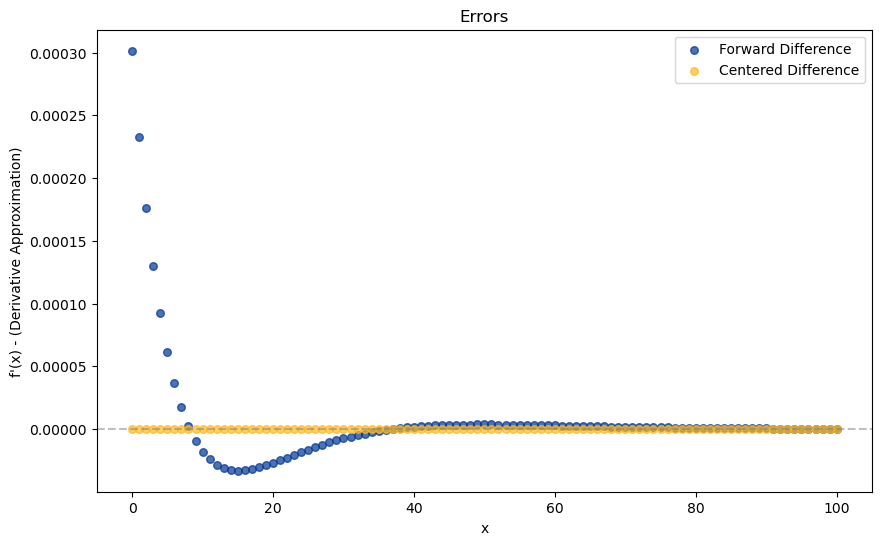

In [18]:
# Calculate the centered derivative for our medium function
x_range = np.arange(0, 101)
c_nd_med_f = np.array([c_num_deriv(med_f, xi, 1e-4) for xi in x_range])
nd_med_f = np.array([num_deriv(med_f, xi, 1e-4) for xi in x_range])

# Define the difference from the true derivative
c_nd_med_f_error = c_nd_med_f - d_med_f(x_range)
nd_med_f_error = nd_med_f - d_med_f(x_range)

# Draw the graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_range, nd_med_f_error, color=PITT_BLUE, s=30, label='Forward Difference', alpha=0.7)
ax.scatter(x_range, c_nd_med_f_error, color=PITT_GOLD, s=30, label='Centered Difference', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel("f'(x) - (Derivative Approximation)")
ax.set_title('Errors')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
plt.show()

# Numerical Solutions to an Equation

## Non-linear Equations

Linear equations have well-defined solutions.
* We know *if* we can solve a system based on the rank of the matrix
* If it's solvable, there's a unique solution
* And we know the exact formula for this solution, through the inverse of the matrix

Non-linear equations are tougher 

While some non-linear equations do have well-defined solutions, if we can invert the non-linear part:
$$ x^4= 12\Rightarrow x = 12^{1/4} $$
others are not easily invertible
$$ x\cdot e^{x^2+3x}= 3$$

In addition, we already know that non-linear equations can admit multiple solutions!

Consider the quadratic formula.
$$ a x^2 +bx +c =0$$
While we do have a closed form solution here, except in very special cases, there are two roots to the equation (which may or may not have real values!) from the formula:
$$ x= \frac{-b\pm\sqrt{b^2-4ac}}{2a}$$

Our aim here will be to come up with simple ways to generate numeric solutions to these non-linear problems

## Numerical Solution
There are lots of more advanced methods, but let's focus on building some intuition for how numerical solution works.

The core-method here is illustrated by the Newton-Rhapson iteration to try to solve the root of a continuous function:
$f(x)=0$

Method Procedure:
* Step 1: Guess an initial solution $x_0$
* Step 2: Figure out the value of the function at this point $f(x_0)$
* Step 3: Figure out the derivative of the funcation here $f^\prime(x_0)$

We then output a new guess
$$ x_1= x_0 - \dfrac{f(x_0)}{f^\prime(x_0)} $$

But then we can use that new guess as an input to find another:
$$ x_2= x_1 - \dfrac{f(x_1)}{f^\prime(x_1)}.$$
And so on, so the induction is that:
$$ x_{n+1}= x_n - \dfrac{f(x_n)}{f^\prime(x_n)},$$
and you stop whenever $|x_{n+1}-x_n|$ is small enough

## Example
As an example, let's consider the function:
$$ f(x)= 2 x^2 - 10 x + 3 $$

### Graphing this:
![Image](i/nr_1.svg)

Consider the function:

$$ f(x)= 2 x^2 - 10 x + 3 $$

Because this is an easy function we know that $ f^\prime(x)= 4 x - 10$.

Method Procedure:
* Step 1: Guess an initial solution $x_0=4$
* Step 2: Figure out the value of the function at this point $f(4)=-5$
* Step 3: Figure out the derivative of the funcation here $f^\prime(4)=6$

We then output a new guess
$$ x_1= x_0 - \dfrac{f(x_0)}{f^\prime(x_0)} = 4-\dfrac{(-5)}{6}=\frac{29}{6}$$

### Step 1 and 2:
![Image](i/nr_2.svg)

### Zooming in
![Image](i/nr_3.svg)

### Finding the derivative
![Image](i/nr_4.svg)

### Putting it all together to get $x_1$
![Image](i/nr_5.svg)

### Figure out $f(x_1)$
![Image](i/nr_6.svg)

### Figure out $f^\prime(x_1)$ to get $x_2$
![Image](i/nr_7.svg)

In [ ]:
def newton_raphson(f, x0, tol=1e-8, eps=1e-6):
    """Basic Newton-Raphson root finding (no max iterations, no NaN check)."""
    xx = x0
    fval = f(xx)
    error = abs(f(xx))
    ii = 1
    while error > tol:
        fd = c_num_deriv(f, xx, eps)  # numerical derivative
        xx = xx - fval / fd          # Newton-Raphson iteration
        fval = f(xx)
        error = abs(fval)
        ii += 1
    print(f"{ii} steps")
    return xx

In [ ]:
# Actual values from quadratic formula
actual_roots = {
    'Low Root': (10 - np.sqrt(100 - 4*2*3)) / 4,
    'High Root': (10 + np.sqrt(100 - 4*2*3)) / 4
}
print(actual_roots)

# Run our approximation
newton_raphson(easy_f, 200)

In [ ]:
print(actual_roots)
# Run it with a higher tolerance
newton_raphson(easy_f, 4, tol=1e-12)

### What happens if we change the starting value?
![Image](i/nr_1.svg)

In [ ]:
print(actual_roots)
newton_raphson(easy_f, 1, tol=1e-8)

Going back to our *medium* function:

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 10, 200)
ax.plot(x, med_f(x), color=PITT_BLUE, linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Function Graph')
plt.show()

In [ ]:
newton_raphson(med_f, 7.5, tol=1e-8)

In [ ]:
newton_raphson(med_f, 5, tol=1e-8)

We also know that  $\left(2 x^2- 10 x+3 \right)\cdot e^{-x/10}=0$ in the limit as $x\rightarrow\infty$

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 200, 400)
ax.plot(x, med_f(x), color=PITT_BLUE, linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Function Graph')
plt.show()

Define a new version of the function that terminates after a certain number of iterations.

In [ ]:
def newton_raphson(f, x0, tol=1e-8, eps=1e-6, maxiter=50):
    """Newton-Raphson with max iterations."""
    xx = x0
    fval = f(xx)
    error = abs(f(xx))
    ii = 1
    while error > tol and ii < maxiter:
        fd = c_num_deriv(f, xx, eps)
        xx = xx - fval / fd
        fval = f(xx)
        error = abs(fval)
        ii += 1
    if ii >= maxiter:
        print("Exited due to non-convergence")
    print(f"{ii} steps")
    return xx

In [ ]:
newton_raphson(med_f, 90, tol=1e-32)

In [ ]:
def med_f_2(x):
    return med_f(x) + 1

fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(10, 415, 400)
ax.plot(x, med_f_2(x), color=PITT_BLUE, linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Function Graph')
plt.show()

In [ ]:
med_f_2(1000000000)

In [ ]:
newton_raphson(med_f_2, 1, 90)

In [ ]:
def newton_raphson(f, x0, tol=1e-8, eps=1e-6, maxiter=50):
    """Newton-Raphson with max iterations and NaN catching."""
    xx = x0
    fval = f(xx)
    error = abs(f(xx))
    ii = 1
    nan_catch = 0
    while error > tol and ii < maxiter and nan_catch == 0:
        fd = c_num_deriv(f, xx, eps)
        print([xx, fd])
        if np.isnan(fd):
            nan_catch = 1
            print("Derivative not defined")
        else:
            xx = xx - fval / fd
            fval = f(xx)
            error = abs(fval)
            ii += 1
    if ii >= maxiter:
        print("Exited due to non-convergence")
    print(f"{ii} steps")
    return xx

In [ ]:
newton_raphson(med_f, 90, tol=1e-8, maxiter=10)
newton_raphson(med_f, 90, tol=1e-8)

Obviously, we shouldn't try to reinvent the wheel here. There are many other solvers which use other clever methods to find roots.

However, sometimes we need to know what we're doing when we use them

In [ ]:
from scipy.optimize import fsolve

In [ ]:
results = [fsolve(med_f_2, x0, full_output=True) for x0 in range(-100, 101)]
roots = np.array([r[0][0] for r in results])

In [ ]:
np.unique(np.round(roots, 5))